In [47]:
import numpy as np
import pandas as pd
from torchvision.datasets import CIFAR10
cifar10_train = CIFAR10(root='./data', train=True, download=True)

In [48]:

image, label = cifar10_train[0]
print(type(image))
print(image.size if hasattr(image, 'size') else image.shape)
print (label)

<class 'PIL.Image.Image'>
(32, 32)
6


In [49]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(60),
    transforms.ToTensor()
])

view1 = transform(image)
view2 = transform(image)
view3 = transform(image)

print(f"View1 shape: {view1.shape}")
print(f"View2 shape: {view2.shape}")
print(f"{torch.equal(view1, view2)}")

View1 shape: torch.Size([3, 32, 32])
View2 shape: torch.Size([3, 32, 32])
False


In [50]:
from torch.utils.data import Dataset
class MultiViewDataset(Dataset):
    def __init__(self, orig_data, transform, num_views= 4):
        self.orig_data = orig_data
        self.transform = transform
        self.num_views = num_views
    
    def __len__(self):
        return len(self.orig_data)

    def __getitem__(self, dataset):
        image, label = self.orig_data[dataset]

        views = []
        for i in range(self.num_views):
            view = self.transform(image)
            views.append(view)
        views = torch.stack(views)
        return views, label

multi_view_cifar10_train = MultiViewDataset(cifar10_train, transform, num_views=4)


In [51]:
print(dir(multi_view_cifar10_train))
views, label = multi_view_cifar10_train[0]
print(f"Views shape: {views.shape}")
print(f"Label: {label}")

['__add__', '__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', 'num_views', 'orig_data', 'transform']
Views shape: torch.Size([4, 3, 32, 32])
Label: 6


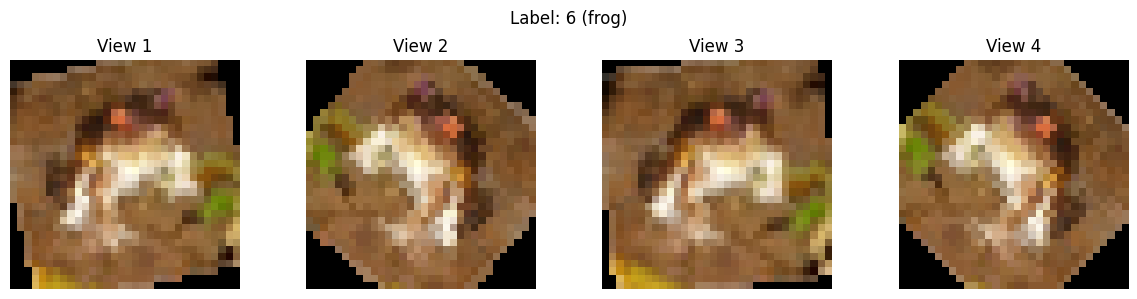

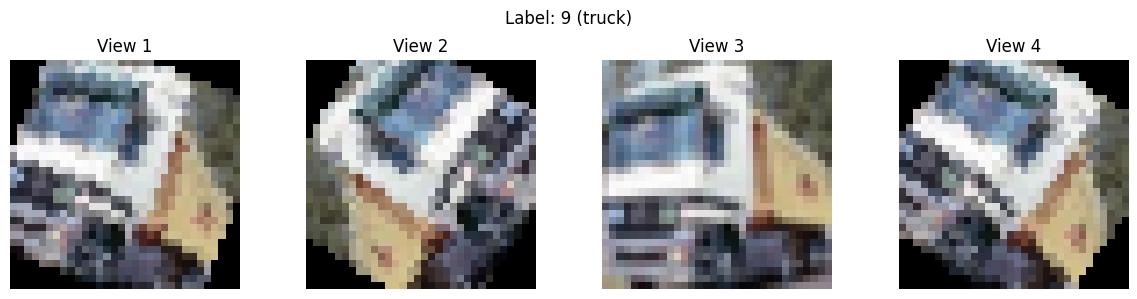

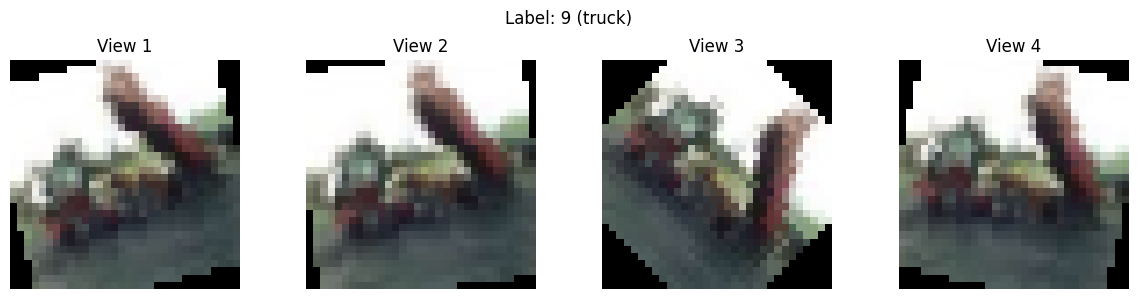

In [52]:
import matplotlib.pyplot as plt
import numpy as np

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
def show_views(dataset, idx=0):
    """Visualize the multiple views of a single image"""
    views, label = dataset[idx]
    
    # views shape: (num_views, 3, 32, 32)
    num_views = views.shape[0]
    
    fig, axes = plt.subplots(1, num_views, figsize=(12, 3))
    
    for i in range(num_views):
        # Convert from (3, 32, 32) to (32, 32, 3) for display
        img = views[i].permute(1, 2, 0).numpy()
        
        # If you normalized, you might need to denormalize
        # For now, clip to [0, 1] range
        img = np.clip(img, 0, 1)
        
        axes[i].imshow(img)
        axes[i].set_title(f'View {i+1}')
        axes[i].axis('off')
    
    plt.suptitle(f'Label: {label} ({classes[label]})')
    plt.tight_layout()
    plt.show()

# Test it
show_views(multi_view_cifar10_train, idx=0)
show_views(multi_view_cifar10_train, idx=1)
show_views(multi_view_cifar10_train, idx=2)

In [53]:
class model_backbone(nn.Module):
     def __init__(self, embedding_dim=84):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 4)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16*5*5, 120)
        self.fc2 = nn.Linear(120, embedding_dim)
         
     def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return x

In [54]:
backbone = model_backbone(embedding_dim=84)
views, label = multi_view_cifar10_train[0]
views[0]
view = views[0].unsqueeze(0)
output = backbone(view)
print(f"Output shape: {output.shape}")
print(output)

Output shape: torch.Size([1, 84])
tensor([[0.0219, 0.0086, 0.0520, 0.0704, 0.0637, 0.0000, 0.0000, 0.0000, 0.0569,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0521, 0.0000, 0.0000, 0.0000, 0.0983,
         0.0000, 0.0000, 0.0693, 0.0626, 0.0000, 0.0051, 0.0265, 0.0631, 0.0503,
         0.0631, 0.0000, 0.0000, 0.0000, 0.0082, 0.0418, 0.0000, 0.0126, 0.0000,
         0.0269, 0.0724, 0.0000, 0.1038, 0.0000, 0.0027, 0.0000, 0.0475, 0.0000,
         0.0768, 0.0000, 0.0437, 0.0389, 0.0788, 0.0000, 0.0806, 0.0020, 0.0000,
         0.0929, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0451, 0.0567,
         0.0000, 0.0000, 0.0569, 0.0000, 0.0000, 0.0000, 0.0494, 0.0193, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0121, 0.0000, 0.0792, 0.0306, 0.0000,
         0.0851, 0.0612, 0.0000]], grad_fn=<ReluBackward0>)


In [55]:
class MultiViewModel(nn.Module):
    def __init__(self, backbone, embedding_dim=84):
        super().__init__()
        self.backbone = backbone
        self.embedding_dim = embedding_dim

    def forward(self, views):
        batch_size, num_views, c, h, w = views.shape
        views_flat = views.view(batch_size*num_views, c, h, w)
        embeddings_flat = self.backbone(views_flat)
        embeddings = embeddings_flat.view(batch_size, num_views, self.embedding_dim)
        return embeddings


In [56]:
multi_view_model = MultiViewModel(backbone, embedding_dim=84)
views, label = multi_view_cifar10_train[0]
views = views.unsqueeze(0)
print(f"INput shape: {views.shape} ")
embeddings = multi_view_model(views)
print(f"Output shape: {embeddings.shape}")

INput shape: torch.Size([1, 4, 3, 32, 32]) 
Output shape: torch.Size([1, 4, 84])


In [57]:
from torch.utils.data import DataLoader

train_loader = DataLoader(multi_view_cifar10_train, batch_size=8, shuffle=True)
views_batch, labels_batch = next(iter(train_loader))
print(f"Batch views shape: {views_batch.shape}")
print(f"Batch labels shape: {labels_batch.shape}")

embeddings_batch = multi_view_model(views_batch)
print(f"Batch embeddings shape: {embeddings_batch.shape}")

Batch views shape: torch.Size([8, 4, 3, 32, 32])
Batch labels shape: torch.Size([8])
Batch embeddings shape: torch.Size([8, 4, 84])


In [58]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim),
            nn.Dropout(dropout)
        )
    
    def forward(self, x):
        attn_output, _ = self.attention(x, x, x)
        x = self.norm1(x + attn_output)
        ff_output = self.ff(x)
        x = self.norm2(x + ff_output)
        return x


In [59]:
transformer_block = TransformerBlock(
    embed_dim=84,
    num_heads=4,
    ff_dim=256,
    dropout=0.1)




In [67]:
class CompleteMultiViewModel(nn.Module):
    def __init__(self, backbone, embed_dim=84, num_heads=4, ff_dim=256, num_classes=10, dropout=0.1):
        super().__init__()
        self.backbone = backbone
        self.transformer = TransformerBlock(embed_dim, num_heads, ff_dim, dropout)
        self.classifier = nn.Linear(embed_dim, num_classes)
        self.embed_dim = embed_dim
    
    def forward(self, views):
        batch_size, num_views, c, h, w = views.shape
        views_flat = views.view(batch_size * num_views, c, h, w)
        embeddings_flat = self.backbone(views_flat)  # (batch*num_views, 84)
        embeddings = embeddings_flat.view(batch_size, num_views, self.embed_dim)
        embeddings = self.transformer(embeddings)
        aggregated = embeddings.mean(dim=1)  # ✅ This is the key aggregation step!
        logits = self.classifier(aggregated)
        return logits

backbone = model_backbone(embedding_dim=84)
final_model = CompleteMultiViewModel(
    backbone=backbone,
    embed_dim=84,
    num_heads=4,
    ff_dim=256,
    num_classes=10,
    dropout=0.1)

views_batch, labels_batch = next(iter(train_loader))
print(f"Input views shape: {views_batch.shape}")  # (batch, 4, 3, 32, 32)
print(f"Labels shape: {labels_batch.shape}")      # (batch,)

# Forward pass
logits = final_model(views_batch)
print(f"Output logits shape: {logits.shape}")     # (batch, 10)

# Get predictions
predictions = logits.argmax(dim=1)
print(f"Predictions shape: {predictions.shape}")  # (batch,)
print(f"Sample predictions: {predictions[:5]}")
print(f"Sample labels: {labels_batch[:5]}")

Input views shape: torch.Size([8, 4, 3, 32, 32])
Labels shape: torch.Size([8])
Output logits shape: torch.Size([8, 10])
Predictions shape: torch.Size([8])
Sample predictions: tensor([8, 8, 8, 8, 8])
Sample labels: tensor([3, 7, 3, 2, 6])


In [73]:
import copy

backbone1 = model_backbone(embedding_dim=84)
model_sgd = CompleteMultiViewModel(
    backbone=backbone1,
    embed_dim=84,
    num_heads=4,
    ff_dim=256,
    num_classes=10,
    dropout=0.1
)

backbone2 = model_backbone(embedding_dim=84)
model_adam = CompleteMultiViewModel(
    backbone=backbone2,
    embed_dim=84,
    num_heads=4,
    ff_dim=256,
    num_classes=10,
    dropout=0.1
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_sgd = model_sgd.to(device)
model_adam = model_adam.to(device)

criterion = nn.CrossEntropyLoss()
optimiser_sgd = torch.optim.SGD(model_sgd.parameters(), lr = 0.001, momentum = 0.9)
optimiser_adam = torch.optim.Adam(model_adam.parameters(), lr = 0.001)


In [74]:
def train_model(model, train_loader, criterion, optimizer, epochs, device, model_name="Model"):
    model.train()  # Set to training mode
    train_losses = []  # Track loss over epochs
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        
        for i, data in enumerate(train_loader):
            views, labels = data
            views, labels = views.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(views)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            if i % 500 == 499:
                print(f'[{model_name}] Epoch {epoch+1}, Batch {i+1}: '
                      f'Loss: {running_loss/500:.3f}, '
                      f'Acc: {100*correct/total:.2f}%')
                running_loss = 0.0
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        print(f'[{model_name}] Epoch {epoch+1}/{epochs} Complete - '
              f'Avg Loss: {epoch_loss:.3f}, Accuracy: {epoch_acc:.2f}%')
    
    print(f'[{model_name}] Training Complete!')
    return train_losses

In [77]:
batch_size = 32

train_loader = DataLoader(
    multi_view_cifar10_train, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=0 
)

print(f"Training batches: {len(train_loader)}")
print(f"Total training samples: {len(multi_view_cifar10_train)}")

Training batches: 1563
Total training samples: 50000


In [78]:
num_epochs = 15

print("=" * 60)
print("TRAINING WITH SGD")
print("=" * 60)
losses_sgd = train_model(
    model_sgd, 
    train_loader, 
    criterion, 
    optimiser_sgd, 
    num_epochs, 
    device, 
    "SGD"
)

print("\n" + "=" * 60)
print("TRAINING WITH ADAM")
print("=" * 60)
losses_adam = train_model(
    model_adam, 
    train_loader, 
    criterion, 
    optimiser_adam, 
    num_epochs, 
    device, 
    "Adam"
)

print("\n" + "=" * 60)
print("TRAINING COMPLETE!")
print("=" * 60)

TRAINING WITH SGD
[SGD] Epoch 1, Batch 500: Loss: 2.183, Acc: 18.06%
[SGD] Epoch 1, Batch 1000: Loss: 1.918, Acc: 23.87%
[SGD] Epoch 1, Batch 1500: Loss: 1.742, Acc: 28.22%
[SGD] Epoch 1/15 Complete - Avg Loss: 0.070, Accuracy: 28.59%
[SGD] Epoch 2, Batch 500: Loss: 1.648, Acc: 40.18%
[SGD] Epoch 2, Batch 1000: Loss: 1.588, Acc: 41.31%
[SGD] Epoch 2, Batch 1500: Loss: 1.569, Acc: 41.98%
[SGD] Epoch 2/15 Complete - Avg Loss: 0.063, Accuracy: 42.07%
[SGD] Epoch 3, Batch 500: Loss: 1.514, Acc: 45.34%
[SGD] Epoch 3, Batch 1000: Loss: 1.477, Acc: 46.16%
[SGD] Epoch 3, Batch 1500: Loss: 1.467, Acc: 46.53%
[SGD] Epoch 3/15 Complete - Avg Loss: 0.058, Accuracy: 46.62%
[SGD] Epoch 4, Batch 500: Loss: 1.414, Acc: 49.66%
[SGD] Epoch 4, Batch 1000: Loss: 1.409, Acc: 49.25%
[SGD] Epoch 4, Batch 1500: Loss: 1.379, Acc: 49.75%
[SGD] Epoch 4/15 Complete - Avg Loss: 0.056, Accuracy: 49.81%
[SGD] Epoch 5, Batch 500: Loss: 1.358, Acc: 51.57%
[SGD] Epoch 5, Batch 1000: Loss: 1.345, Acc: 51.86%
[SGD] Epoch